# 2.0 — Ingeniería de Features RFM
**Autor:** Ian Gallego | Politécnico Malvinas Argentinas | 2026

---
Toma `data/interim/transacciones_limpias.parquet`, agrupa por `id_cliente` y construye
la tabla nivel cliente con las variables **RFM** (clustering) y **complementarias**
(caracterización). Aplica log a `monetary` y persiste en `data/processed/clientes_rfm.parquet`.

## 1. Carga del intermedio limpio

In [1]:
# Setup: agregar el root del proyecto al sys.path para importar segmentacion/
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from segmentacion.features import construir_tabla_clientes, aplicar_log_monetary, guardar_clientes
from segmentacion.plots import histograma_features, boxplots_features
from segmentacion.config import INTERIM_DATA_DIR, FIGURES_DIR

df = pd.read_parquet(INTERIM_DATA_DIR / 'transacciones_limpias.parquet')
print(f'Transacciones limpias: {len(df):,}')
df.head()

2026-06-03 20:02:06.814 | INFO     | segmentacion.config:<module>:11 - PROJ_ROOT path is: F:\CIENCIA DE DATOS2026\CienciadeDatos\Aprendisajeautomatico\TrabajoFinalApAut


Transacciones limpias: 49,909


,id_transaccion,id_cliente,fecha,categoria_producto,cantidad_items,monto_total,canal_venta,medio_pago,localidad
0,TX-000001,CLI-00514,2024-06-02,Herramientas manuales,3,35488.78,Web,Tarjeta de débito,Tolhuin
1,TX-000003,CLI-05671,2024-06-03,Seguridad e indumentaria,4,176857.58,App,Cuenta corriente,Río Grande
2,TX-000004,CLI-01439,2024-06-05,Maderas y tableros,4,50604.82,Web,Tarjeta de crédito,Río Grande
3,TX-000006,CLI-05345,2024-06-06,Pinturas y revestimientos,3,45027.38,Web,Tarjeta de débito,Ushuaia
4,TX-000007,CLI-05417,2024-06-07,Aberturas,2,136571.52,App,Efectivo en sucursal,Río Grande


## 1.5 — Deflactación por inflación
El dataset sintético modela inflación en `monto_total` (ARS) a lo largo de 24 meses.
Si calculamos el Monetary directamente sobre `monto_total`, los clientes recientes
aparecerán artificialmente más valiosos que los antiguos por el solo efecto del
incremento de precios. Estimamos un **deflactor mensual** ajustando una curva
exponencial a la **mediana de `monto_total`** por mes (la mediana evita el sesgo
de los outliers B2B) y agregamos la columna `monto_total_real` en pesos del
primer mes del dataset (2024-06).

2026-06-03 20:02:08.427 | INFO     | segmentacion.inflacion:estimar_deflactor:57 - Deflactor estimado: a=69371.77, b=0.0420/mes (inflacion mensual ~4.29%, acumulada 162.9% en 24 meses)


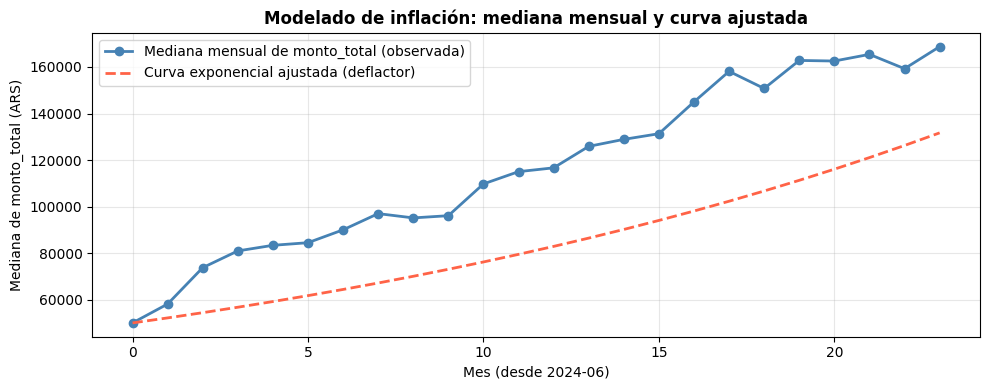


Deflactor por periodo (extracto):
periodo
2024-06    1.000000
2024-07    1.042922
2024-08    1.087685
2024-09    1.134370
2024-10    1.183059
Freq: M, Name: deflactor, dtype: float64
...
periodo
2026-01    2.222190
2026-02    2.317569
2026-03    2.417043
2026-04    2.520786
2026-05    2.628982
Freq: M, Name: deflactor, dtype: float64


In [2]:
from segmentacion.inflacion import estimar_deflactor, deflactar
from segmentacion.modeling.train import guardar_modelo
from segmentacion.config import MODELS_DIR

deflactor = estimar_deflactor(df)

fig, ax = plt.subplots(figsize=(10, 4))
df_aux = df.copy()
df_aux['periodo'] = df_aux['fecha'].dt.to_period('M')
mediana_mes = df_aux.groupby('periodo')['monto_total'].median().sort_index()
ax.plot(range(len(mediana_mes)), mediana_mes.values, marker='o', color='steelblue',
        linewidth=2, label='Mediana mensual de monto_total (observada)')
valor_base = mediana_mes.values[0]
ax.plot(range(len(deflactor)), valor_base * deflactor.values, linestyle='--',
        color='tomato', linewidth=2, label='Curva exponencial ajustada (deflactor)')
ax.set_xlabel('Mes (desde 2024-06)')
ax.set_ylabel('Mediana de monto_total (ARS)')
ax.set_title('Modelado de inflación: mediana mensual y curva ajustada',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb2_deflactor.png', dpi=120, bbox_inches='tight')
plt.show()

print()
print('Deflactor por periodo (extracto):')
print(deflactor.head())
print('...')
print(deflactor.tail())

In [3]:
df = deflactar(df, deflactor)
guardar_modelo(deflactor, MODELS_DIR / 'deflactor.joblib')

print('Columnas de df:', list(df.columns))
print(f'monto_total max:      {df.monto_total.max():>15,.0f} ARS (nominal)')
print(f'monto_total_real max: {df.monto_total_real.max():>15,.0f} ARS (2024-06)')

2026-06-03 20:02:08.804 | INFO     | segmentacion.inflacion:deflactar:71 - Deflactacion aplicada. monto_total max nominal: 37,383,912 ARS  ->  max real (2024-06): 15,466,797 ARS
2026-06-03 20:02:08.807 | SUCCESS  | segmentacion.modeling.train:guardar_modelo:117 - Modelo guardado: F:\CIENCIA DE DATOS2026\CienciadeDatos\Aprendisajeautomatico\TrabajoFinalApAut\models\deflactor.joblib
Columnas de df: ['id_transaccion', 'id_cliente', 'fecha', 'categoria_producto', 'cantidad_items', 'monto_total', 'canal_venta', 'medio_pago', 'localidad', 'monto_total_real']
monto_total max:           37,383,912 ARS (nominal)
monto_total_real max:      15,466,797 ARS (2024-06)


## 2. Construcción de la tabla por cliente
**fecha_corte dinámica** = `df['fecha'].max()` (no hardcoded).

In [4]:
clientes = construir_tabla_clientes(df)
print(f'\nClientes: {len(clientes):,}')
clientes.describe().round(2)

2026-06-03 20:02:08.826 | INFO     | segmentacion.features:construir_tabla_clientes:42 - Fecha de corte usada para RFM: 2026-05-31
2026-06-03 20:02:08.856 | INFO     | segmentacion.features:construir_tabla_clientes:80 - Tabla de clientes: 4,992 filas x 8 columnas

Clientes: 4,992


,recency,frequency,monetary,monetary_nominal,ticket_promedio,diversidad_categorias,antiguedad
count,4992.00,4992.00,4992.00,4992.00,4992.00,4992.00,4992.00
mean,231.00,10.00,1615048.70,2899752.43,94553.92,5.34,476.54
std,201.68,9.86,3579116.25,6540355.27,93009.59,3.15,186.05
min,0.00,1.00,1533.69,1668.17,1533.69,1.00,2.00
25%,42.00,3.00,148480.72,232502.80,40015.98,3.00,355.75
50%,181.00,7.00,414524.53,673418.48,63288.78,5.00,550.00
75%,396.00,14.00,1011000.81,1807177.44,101959.57,8.00,611.25
max,723.00,69.00,38280340.10,85027776.41,1064324.04,13.00,728.00


## 3. Distribuciones de las features

2026-06-03 20:02:09.753 | INFO     | segmentacion.plots:_save:19 - Figura guardada: F:\CIENCIA DE DATOS2026\CienciadeDatos\Aprendisajeautomatico\TrabajoFinalApAut\reports\figures\nb2_histogramas.png


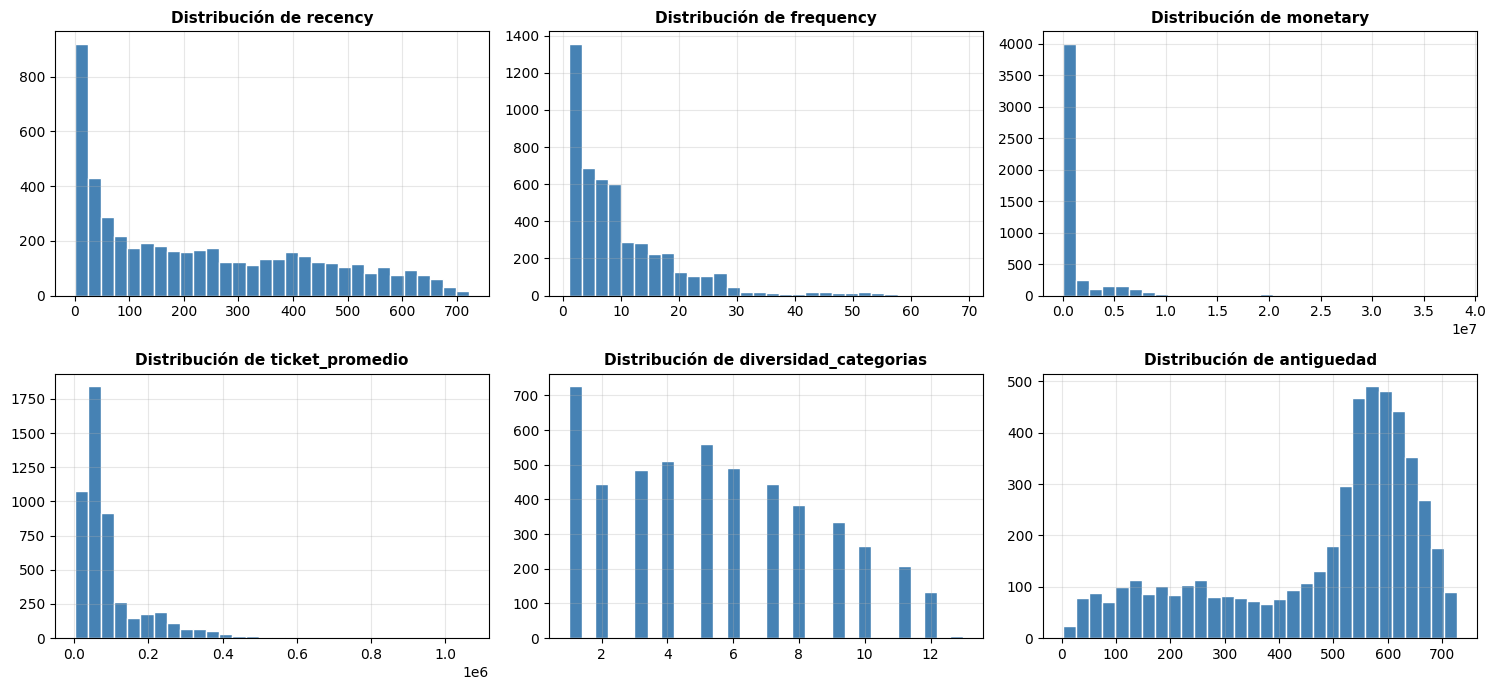

In [5]:
cols = ['recency', 'frequency', 'monetary', 'ticket_promedio', 'diversidad_categorias', 'antiguedad']
histograma_features(clientes, cols, output=FIGURES_DIR / 'nb2_histogramas.png')
plt.show()

2026-06-03 20:02:10.716 | INFO     | segmentacion.plots:_save:19 - Figura guardada: F:\CIENCIA DE DATOS2026\CienciadeDatos\Aprendisajeautomatico\TrabajoFinalApAut\reports\figures\nb2_boxplots.png


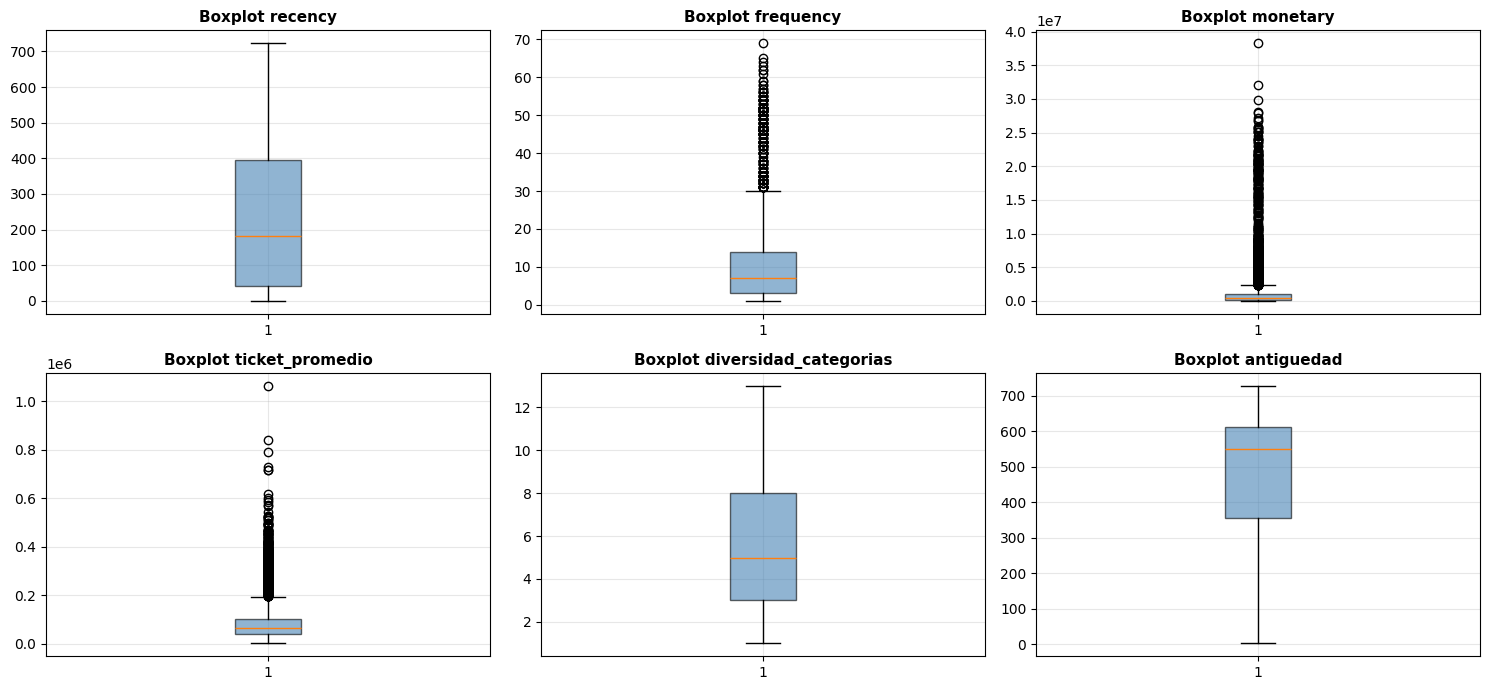

In [6]:
boxplots_features(clientes, cols, output=FIGURES_DIR / 'nb2_boxplots.png')
plt.show()

## 4. Log-transformación de monetary
La distribución de `monetary` está muy sesgada a la derecha (típico en e-commerce: pocos
clientes B2B compran montos enormes). Agregamos `monetary_log = log1p(monetary)` para que
los algoritmos basados en distancia no se vean dominados por la escala de los grandes
compradores. **No se transforman** `recency` ni `frequency` (contadores discretos).

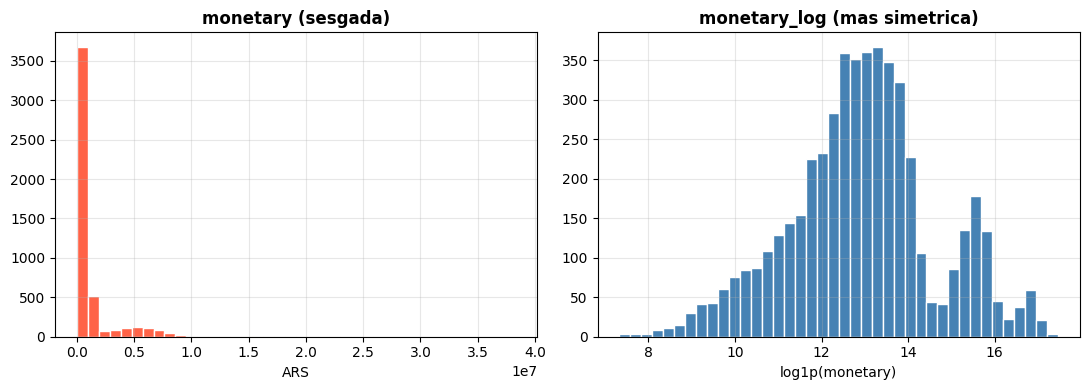

In [7]:
clientes = aplicar_log_monetary(clientes)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(clientes['monetary'], bins=40, color='tomato', edgecolor='white')
axes[0].set_title('monetary (sesgada)', fontweight='bold')
axes[0].set_xlabel('ARS')
axes[0].grid(alpha=0.3)
axes[1].hist(clientes['monetary_log'], bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('monetary_log (mas simetrica)', fontweight='bold')
axes[1].set_xlabel('log1p(monetary)')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb2_monetary_log.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Persistencia

In [8]:
path = guardar_clientes(clientes)
print(f'Listo. Tabla de clientes: {path}')
print(f'Columnas: {list(clientes.columns)}')

2026-06-03 20:02:11.569 | SUCCESS  | segmentacion.features:guardar_clientes:110 - Guardado processed: F:\CIENCIA DE DATOS2026\CienciadeDatos\Aprendisajeautomatico\TrabajoFinalApAut\data\processed\clientes_rfm.parquet
Listo. Tabla de clientes: F:\CIENCIA DE DATOS2026\CienciadeDatos\Aprendisajeautomatico\TrabajoFinalApAut\data\processed\clientes_rfm.parquet
Columnas: ['id_cliente', 'recency', 'frequency', 'monetary', 'monetary_nominal', 'ticket_promedio', 'diversidad_categorias', 'antiguedad', 'monetary_log']


## 📋 TL;DR del notebook 2
- **Entrada:** `data/interim/transacciones_limpias.parquet`
- **Salidas:** `data/processed/clientes_rfm.parquet` (4.992 clientes) + `models/deflactor.joblib`
- **Decisión clave:** **deflactar** `monto_total` antes del Monetary (inflación acumulada ~160 % en 24 meses)
- **Features generadas:** RFM (clustering) + ticket_promedio / diversidad / antigüedad (caracterización)
- **Siguiente paso:** notebook 3 → EDA del dataset RFM (correlaciones, B2B/B2C)